# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [2]:
data = pd.read_csv (r'data\nndb_flat.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


In [4]:
# 45 columnas: 6 categóricas y el resto numéricas. Hay muchos nulos en un par de ellas

### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

<Axes: >

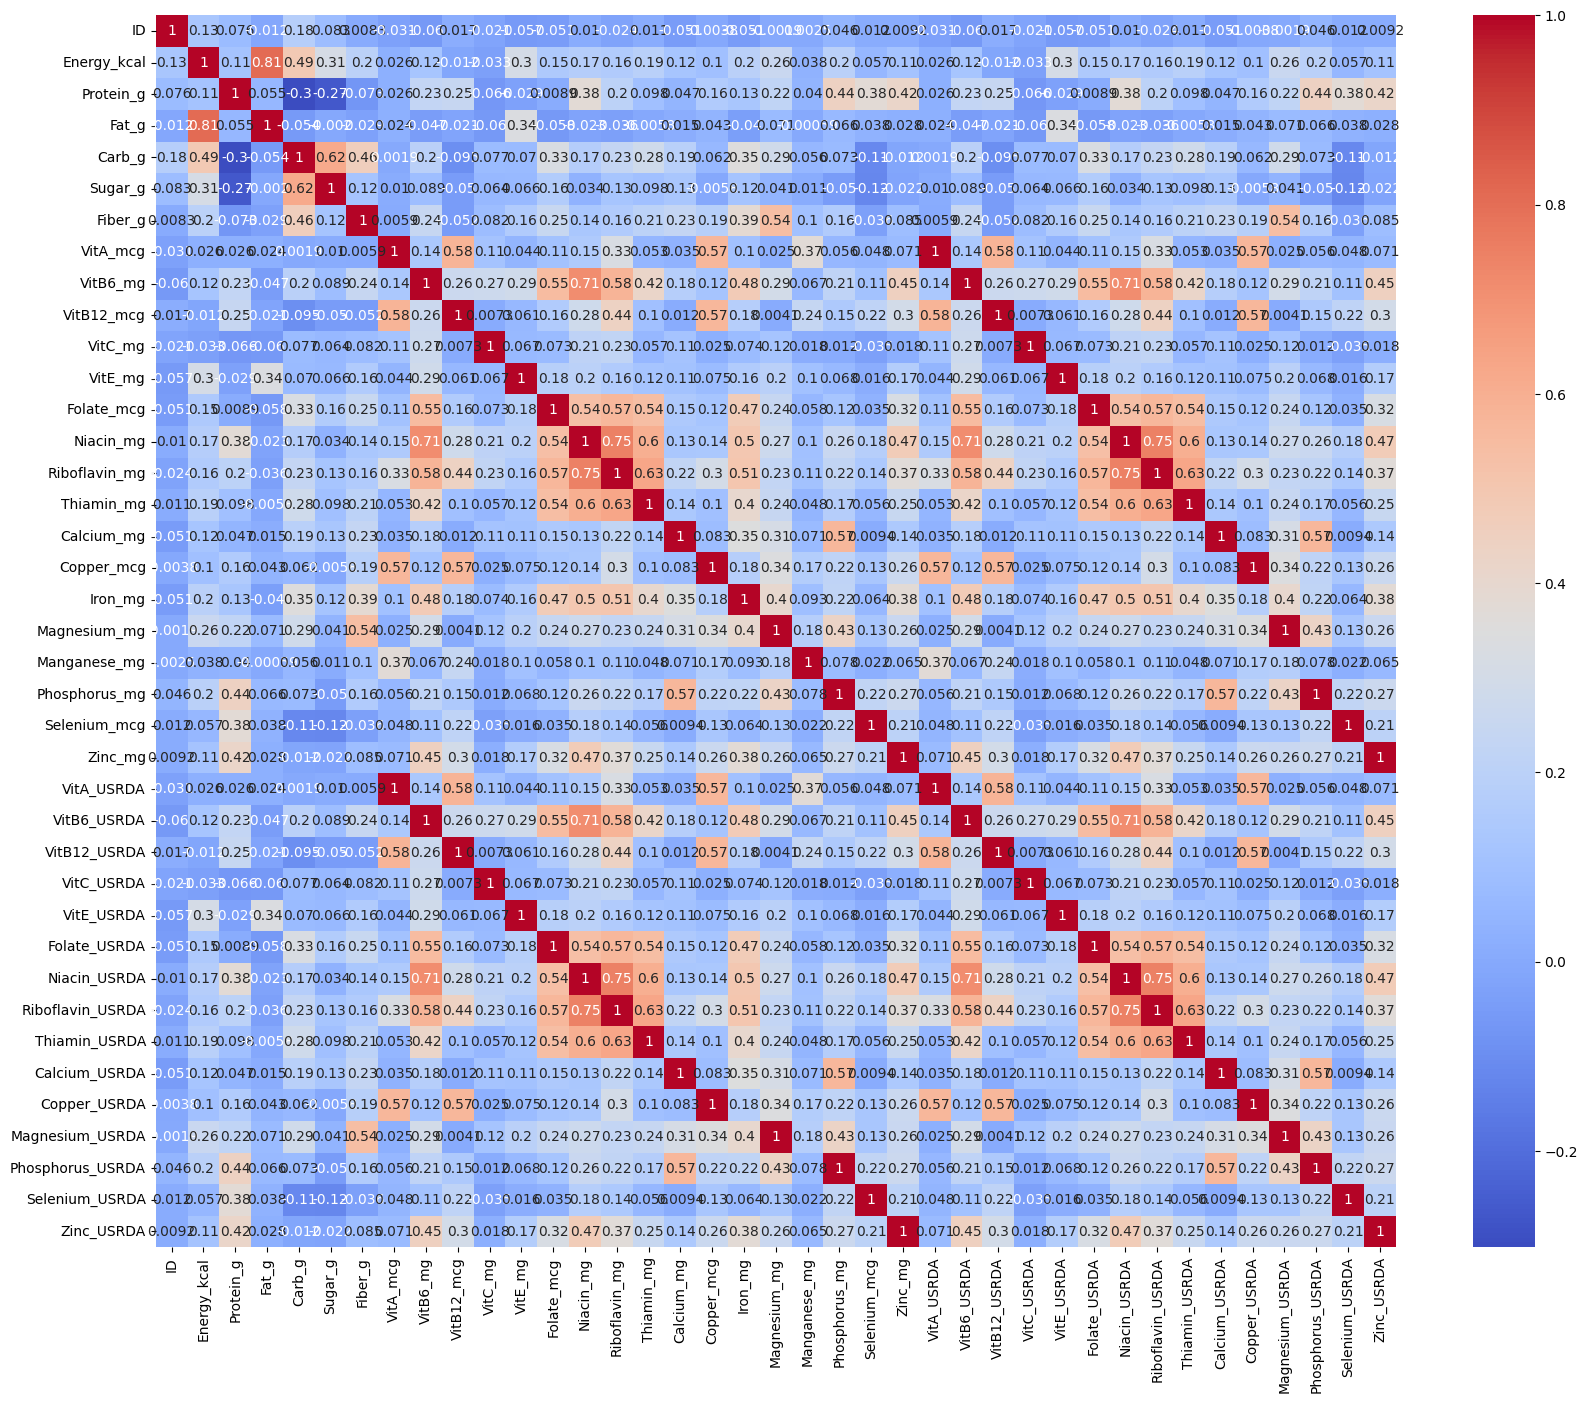

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))  # ajusta el tamaño (ancho, alto)
sns.heatmap (data.corr (numeric_only=True), annot=True, cmap='coolwarm')

In [6]:
# Todas las variables USRDA tienen correlación 1 con su equivalente _mcg o _mg. No aportan información nueva 
# así que podrían quitarse
data_copy = data.drop (columns=data.columns[data.columns.str.contains("USRDA")])


### Variables no numéricas
Elimina las variables de texto del dataset

In [7]:
data_copy.head()
data_copy = data_copy.select_dtypes(include=['number'])

### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'Energy_kcal'}>,
        <Axes: title={'center': 'Protein_g'}>,
        <Axes: title={'center': 'Fat_g'}>,
        <Axes: title={'center': 'Carb_g'}>],
       [<Axes: title={'center': 'Sugar_g'}>,
        <Axes: title={'center': 'Fiber_g'}>,
        <Axes: title={'center': 'VitA_mcg'}>,
        <Axes: title={'center': 'VitB6_mg'}>,
        <Axes: title={'center': 'VitB12_mcg'}>],
       [<Axes: title={'center': 'VitC_mg'}>,
        <Axes: title={'center': 'VitE_mg'}>,
        <Axes: title={'center': 'Folate_mcg'}>,
        <Axes: title={'center': 'Niacin_mg'}>,
        <Axes: title={'center': 'Riboflavin_mg'}>],
       [<Axes: title={'center': 'Thiamin_mg'}>,
        <Axes: title={'center': 'Calcium_mg'}>,
        <Axes: title={'center': 'Copper_mcg'}>,
        <Axes: title={'center': 'Iron_mg'}>,
        <Axes: title={'center': 'Magnesium_mg'}>],
       [<Axes: title={'center': 'Manganese_mg'}>,
        <Axes: tit

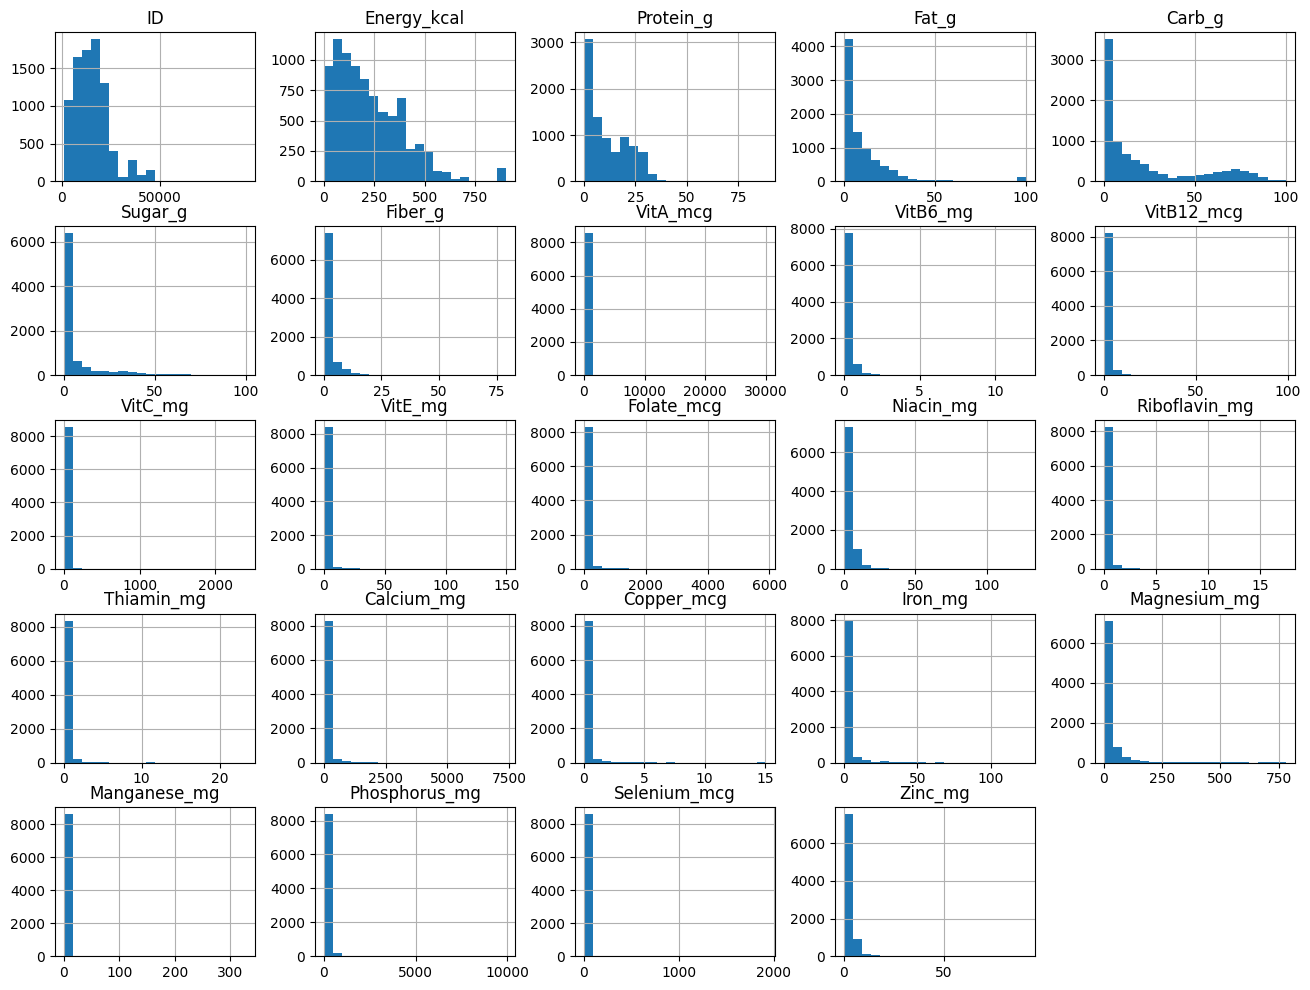

In [8]:
# Qué distribuciones tienen
data_copy.hist(figsize=(16,12), bins=20)

In [9]:
# Acabo de darme cuenta de que no he quitado el ID
data_copy = data_copy.drop (columns= 'ID')

In [10]:
# Aplico transformación logarítimica 1 + log por si hubiera ceros
data_copy = np.log1p (data_copy)

array([[<Axes: title={'center': 'Energy_kcal'}>,
        <Axes: title={'center': 'Protein_g'}>,
        <Axes: title={'center': 'Fat_g'}>,
        <Axes: title={'center': 'Carb_g'}>,
        <Axes: title={'center': 'Sugar_g'}>],
       [<Axes: title={'center': 'Fiber_g'}>,
        <Axes: title={'center': 'VitA_mcg'}>,
        <Axes: title={'center': 'VitB6_mg'}>,
        <Axes: title={'center': 'VitB12_mcg'}>,
        <Axes: title={'center': 'VitC_mg'}>],
       [<Axes: title={'center': 'VitE_mg'}>,
        <Axes: title={'center': 'Folate_mcg'}>,
        <Axes: title={'center': 'Niacin_mg'}>,
        <Axes: title={'center': 'Riboflavin_mg'}>,
        <Axes: title={'center': 'Thiamin_mg'}>],
       [<Axes: title={'center': 'Calcium_mg'}>,
        <Axes: title={'center': 'Copper_mcg'}>,
        <Axes: title={'center': 'Iron_mg'}>,
        <Axes: title={'center': 'Magnesium_mg'}>,
        <Axes: title={'center': 'Manganese_mg'}>],
       [<Axes: title={'center': 'Phosphorus_mg'}>,
       

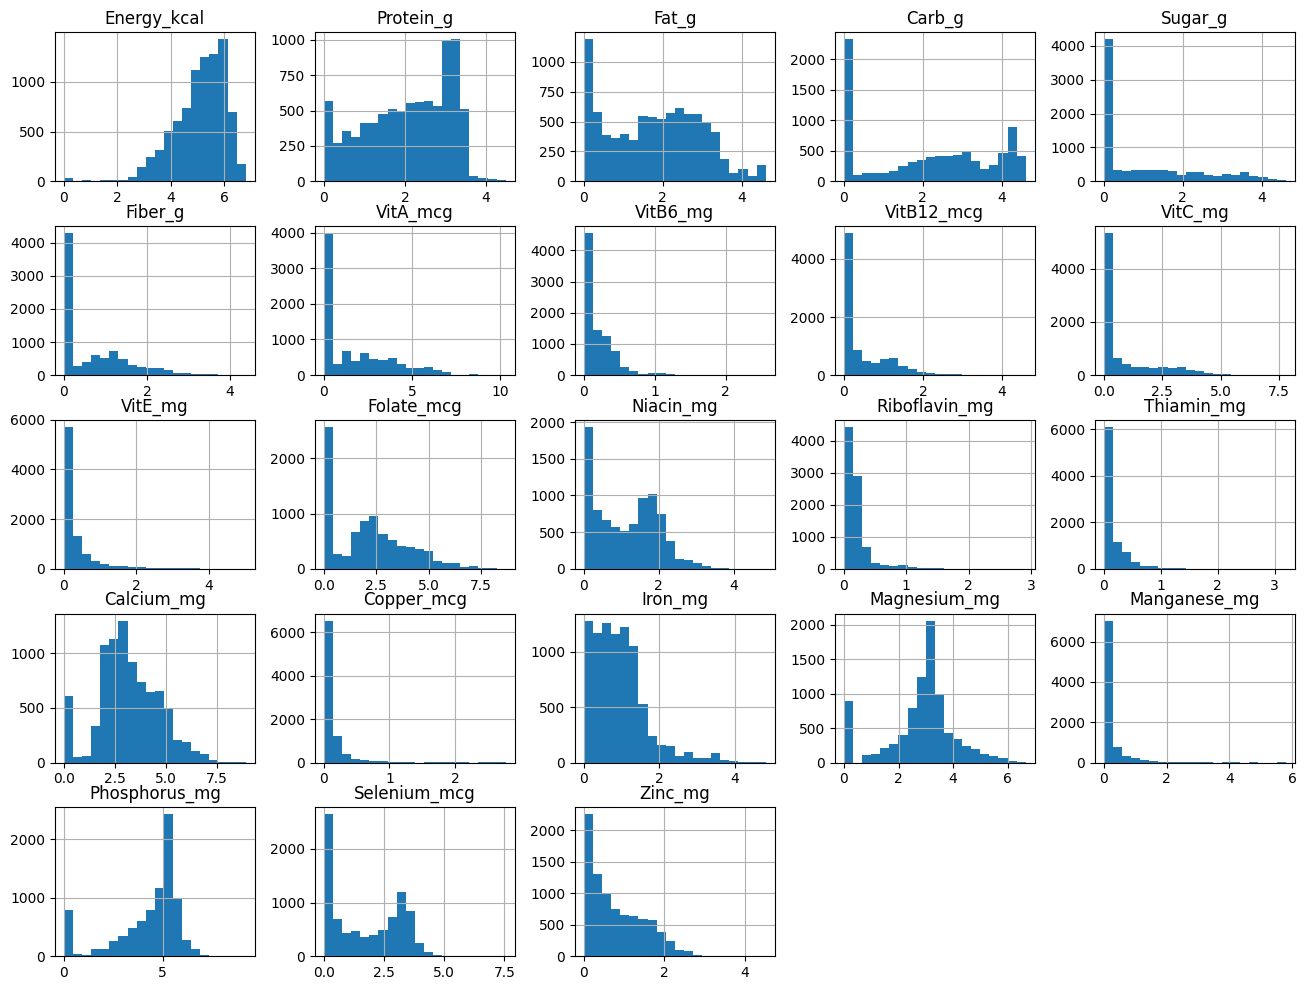

In [11]:
# Cómo quedan
data_copy.hist(figsize=(16,12), bins=20)

### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [12]:
# Aplico un estandard scaler para estandarizar
scaler = StandardScaler()
data_scaled = scaler.fit_transform (data_copy)

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [13]:
# Hago un pca con los 23 y lo aplico a los datos
pca_23 = PCA (23)
X_pca = pca_23.fit_transform(data_scaled)

### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

In [14]:
# Lo que aporta cada una
pca_23.explained_variance_ratio_

array([0.3125111 , 0.16666503, 0.08532219, 0.07111741, 0.05904531,
       0.04487789, 0.03079514, 0.02718658, 0.02537361, 0.02262291,
       0.02194625, 0.01905314, 0.01852623, 0.01432524, 0.01349698,
       0.01297861, 0.01120283, 0.00974457, 0.00929553, 0.00746957,
       0.00693989, 0.00566242, 0.00384157])

In [15]:
# La suma acumulativa:
var_acum = pca_23.explained_variance_ratio_.cumsum()
var_acum

array([0.3125111 , 0.47917612, 0.56449832, 0.63561572, 0.69466103,
       0.73953892, 0.77033406, 0.79752064, 0.82289426, 0.84551716,
       0.86746341, 0.88651656, 0.90504278, 0.91936803, 0.93286501,
       0.94584362, 0.95704645, 0.96679102, 0.97608654, 0.98355611,
       0.99049601, 0.99615843, 1.        ])

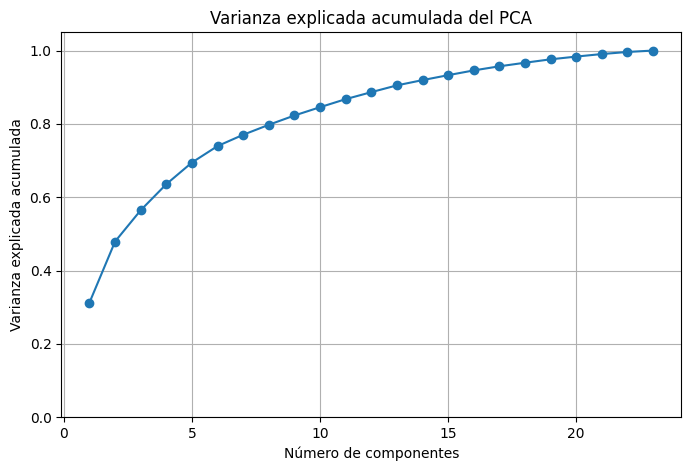

In [16]:
#En gráfico
plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')

plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada del PCA')

plt.ylim(0, 1.05)
plt.grid(True)

plt.show()

In [ ]:
# Con 6 componentes ya se tiene una varianza acumulada de 0.73953892 (el número se ve en el array arriba)
# (entre 70 y 75)

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [17]:
pca_6 = PCA (6)
X_pca6 = pca_6.fit_transform(data_scaled)

In [18]:
# Lo paso a dataframe
proyecciones = pd.DataFrame(
    X_pca6,
    columns = ['PC1', 'PC2', 'PC3', 'PC4','PC5','PC6'],
    index   = data.index
)

In [19]:
proyecciones.shape

(8618, 6)

### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [20]:
# Tengo que volver a incluir la columna FoodGroup (que me había cargado sin copia). He vuelto arriba a trabajar
# sobre una copia del dataset original
proyecciones['FoodGroup'] = data['FoodGroup'].values

In [21]:
# Para cada columna nueva (los 7 PCs) 
for col in proyecciones.columns[:-1]:  # todas menos FoodGroup que es la última
    print(f"\n{col}")
    print(proyecciones.groupby('FoodGroup')[col]
          .mean()                       # calculo la media por cada tipo de Foodgroup
          .sort_values(ascending=False) # ordeno para cada PC de mayor a menor
          .head(3))                             # me quedo con los 3 primeros


PC1
FoodGroup
Breakfast Cereals        4.020261
Nut and Seed Products    3.120684
Spices and Herbs         2.562117
Name: PC1, dtype: float64

PC2
FoodGroup
Spices and Herbs         3.647736
Breakfast Cereals        2.748076
Nut and Seed Products    2.267573
Name: PC2, dtype: float64

PC3
FoodGroup
Fats and Oils            2.333724
Baked Products           1.727793
Nut and Seed Products    1.241486
Name: PC3, dtype: float64

PC4
FoodGroup
Breakfast Cereals    2.265027
Fats and Oils        1.045026
Beverages            0.545486
Name: PC4, dtype: float64

PC5
FoodGroup
Fats and Oils             2.634166
Dairy and Egg Products    1.555680
Baby Foods                0.929960
Name: PC5, dtype: float64

PC6
FoodGroup
Fats and Oils            2.054032
Nut and Seed Products    1.762298
Spices and Herbs         1.461075
Name: PC6, dtype: float64
